# 1. Import libraries

*****This ipynb file is used to visualize the dataset used in the project, to be specific, sarcasm detection dataset and sentiment analysis dataset used in multitask learning and emotion classification dataset used in emotion classification. Cause in the project, I have came up with a new idea when doing the emotion classification which is embed the sentiment label into the word embedding, in order to improve the accuracy of the model, hence, a proper dataset is neccessary for the task. Because of this, I made use of a wide used dataset called "emotions", and in order to fit in the task, some operations will need to be conducted, which has been listed in the following file in detail.*****

In [9]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud

# 2. Read dataset and visualization
In the task, two separate datasets are needed for multitask learning (including sentiment analysis and sarcasm detection) and emotion classification. In the following file, ec represents emotion classification and sd represents sarcasm detection.

In [2]:
# read emotion classification dataset
ec_dataset = pd.read_csv('/kaggle/input/emotions/text.csv')
# read sarcamsm detection dataset
sd_dataset = pd.read_csv('/kaggle/input/thesis2/sarcasm_dataset.csv')
# read sentiment analysis dataset
# in order to compare the result gotten from multitask learning, I use this dataset which have been used by other authors, hence can provide a better result comparison
sa_dataset = pd.read_csv("/kaggle/input/twitter-and-reddit-sentimental-analysis-dataset/Reddit_Data.csv")

## (a) Emotion Classification dataset

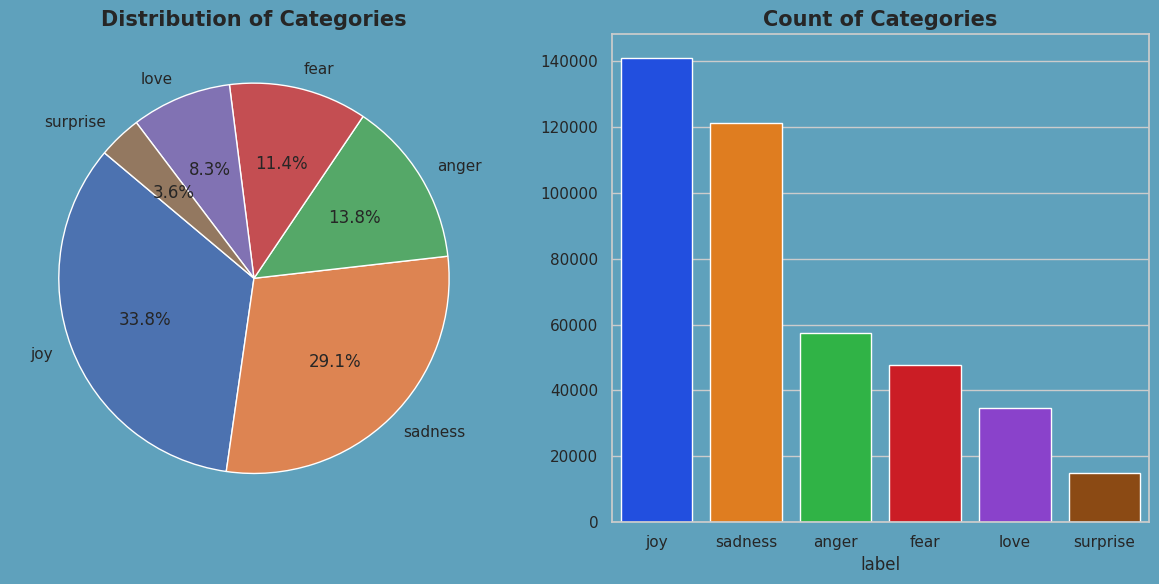

In [3]:
vis_dataset = pd.read_csv('/kaggle/input/emotions/text.csv')
emotion_map = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',
    5: 'surprise'
    # Add more mappings as needed
}

vis_dataset['label'] = vis_dataset['label'].map(emotion_map)
# Value count of 'label'
count = vis_dataset['label'].value_counts()

# Set the background color and theme
background_color = '#5fa1bc'
sns.set_theme(style="whitegrid", rc={"axes.facecolor": background_color, 'figure.facecolor': background_color})

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6), facecolor=background_color)

# Plot pie chart on the first subplot
palette = sns.color_palette("bright", len(count))
sns.set_palette(palette)
axs[0].pie(count, labels=count.index, autopct='%1.1f%%', startangle=140)
axs[0].set_title('Distribution of Categories', fontsize=15, fontweight='bold')

# Plot bar chart on the second subplot
sns.barplot(x=count.index, y=count.values, ax=axs[1], palette=palette)
axs[1].set_title('Count of Categories', fontsize=15, fontweight='bold')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

***It is clear that the dataset is quite unbalanced.Label 'surprise' only contains less than 20k data. In order to get each data its sentiment label, I need to classify data into sentiment labels. It is clear that, joy, love are positive, and sadness, anger, fear are negative, however, it is hard to get the sentiment from surprise, since it can be either surprise in positive or negative way, hence I tend to delete the 'surprise' label, and since there is no neutral label, I tend to copy similar context with neutral label into this dataset.It is clear that the dataset is quite unbalanced.Label 'surprise' only contains less than 20k data. In order to get each data its sentiment label, I need to classify data into sentiment labels. It is clear that, joy, love are positive, and sadness, anger, fear are negative, however, it is hard to get the sentiment from surprise, since it can be either surprise in positive or negative way, hence I tend to delete the 'surprise' label, and since there is no neutral label, I tend to copy similar context with neutral label into this dataset.It is clear that the dataset is quite unbalanced.Label 'surprise' only contains less than 20k data. In order to get each data its sentiment label, I need to classify data into sentiment labels. It is clear that, joy, love are positive, and sadness, anger, fear are negative, however, it is hard to get the sentiment from surprise, since it can be either surprise in positive or negative way, hence I tend to delete the 'surprise' label, and since there is no neutral label, I tend to copy similar context with neutral label into this dataset.It is clear that the dataset is quite unbalanced.Label 'surprise' only contains less than 20k data. In order to get each data its sentiment label, I need to classify data into sentiment labels. It is clear that, joy, love are positive, and sadness, anger, fear are negative, however, it is hard to get the sentiment from surprise, since it can be either surprise in positive or negative way, hence I tend to delete the 'surprise' label.***

***Since there is no neutral label, and for current dataset which has both sentiment and emotion labels, most of them at least have certain kinds of shortcomings, such as lack the number of data, labels unclear, dataset unbalanced, lack of neutral, hence I tend to do some modifications on several datasets to make it a balanced dataset including both sentiment and emotions labels for tasks similar my project, and I will test the method performance on the dataset. In the comparison part, I will test performance on balanced (dataset modified by me) and unbalanced dataset ('emotions' dataset with no 'surprise' label) respectively, which can have a comprehensive analysis on the method proposed.***

## (b) Sarcasm Detection dataset

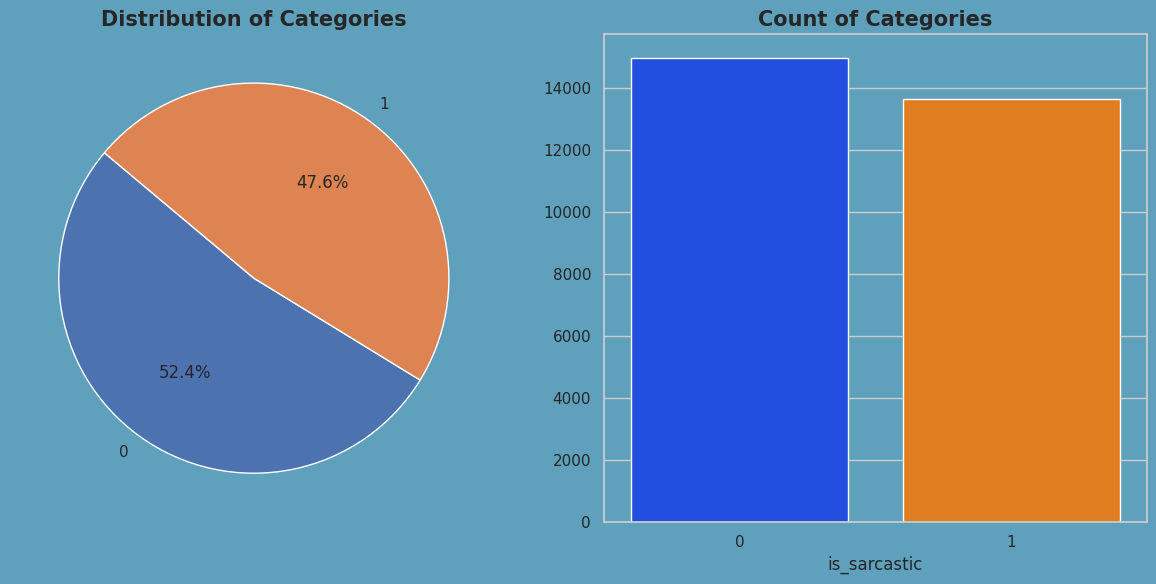

In [4]:
vis_dataset = pd.read_csv('/kaggle/input/thesis2/sarcasm_dataset.csv')
# Value count of 'label'
count = vis_dataset['is_sarcastic'].value_counts()
emotion_map = {
    0: 'not sarcastic',
    1: 'sarcastic',
    # Add more mappings as needed
}

vis_dataset['is_sarcastic'] = vis_dataset['is_sarcastic'].map(emotion_map)
# Set the background color and theme
background_color = '#5fa1bc'
sns.set_theme(style="whitegrid", rc={"axes.facecolor": background_color, 'figure.facecolor': background_color})

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6), facecolor=background_color)

# Plot pie chart on the first subplot
palette = sns.color_palette("bright", len(count))
sns.set_palette(palette)
axs[0].pie(count, labels=count.index, autopct='%1.1f%%', startangle=140)
axs[0].set_title('Distribution of Categories', fontsize=15, fontweight='bold')

# Plot bar chart on the second subplot
sns.barplot(x=count.index, y=count.values, ax=axs[1], palette=palette)
axs[1].set_title('Count of Categories', fontsize=15, fontweight='bold')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

*It is slightly unbalanced, however, in order to **Control Variable** to compare with other work, the dataset cannot be changed.*

## (c) Sentiment Analysis dataset

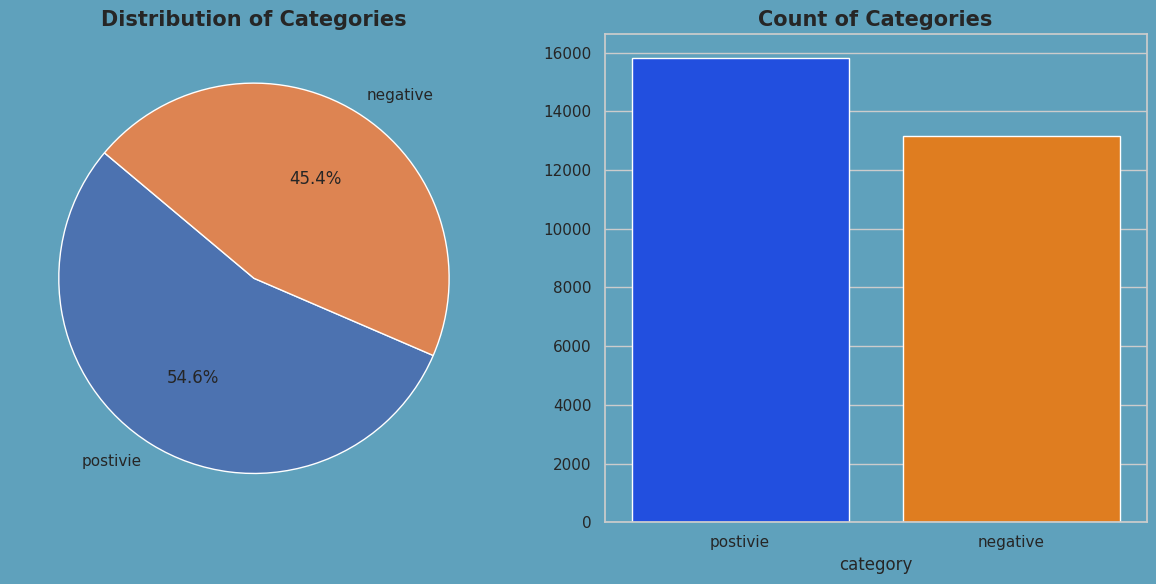

In [5]:
vis_dataset = pd.read_csv('/kaggle/input/twitter-and-reddit-sentimental-analysis-dataset/Reddit_Data.csv')
emotion_map = {
    0: 'negative',
    1: 'postivie',
    # Add more mappings as needed
}

vis_dataset['category'] = vis_dataset['category'].map(emotion_map)
# Value count of 'label'
count = vis_dataset['category'].value_counts()

# Set the background color and theme
background_color = '#5fa1bc'
sns.set_theme(style="whitegrid", rc={"axes.facecolor": background_color, 'figure.facecolor': background_color})

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6), facecolor=background_color)

# Plot pie chart on the first subplot
palette = sns.color_palette("bright", len(count))
sns.set_palette(palette)
axs[0].pie(count, labels=count.index, autopct='%1.1f%%', startangle=140)
axs[0].set_title('Distribution of Categories', fontsize=15, fontweight='bold')

# Plot bar chart on the second subplot
sns.barplot(x=count.index, y=count.values, ax=axs[1], palette=palette)
axs[1].set_title('Count of Categories', fontsize=15, fontweight='bold')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

*It is also slightly unbalanced, however, in order to **Control Variable** to compare with other work, the dataset cannot be changed.*

# 3. Dataset refining

***In this part, I will drop the data with label = 5, which is surprise. Besides, I will add one more column which is sentiment, and set sentiment = 0 when 'label' = 0, 3, 4, which are sadness, anger and fear respectively, they all represent the negative feeling, and for 1, 2, they will be labeled as 1 which is positive. Eventually, I will save them and split them into 80% training dataset and 20% testing dataset for training and evaluation respectively.***

In [44]:
# read emotion classification dataset
ec_dataset = pd.read_csv('/kaggle/input/emotions/text.csv')
# Drop data with 'label' = 5
ec_dataset = ec_dataset[ec_dataset['label'] != 5][['text', 'label']]

In [45]:
# visualize data
print(ec_dataset.head())
print(ec_dataset['label'].value_counts())

                                                text  label
0      i just feel really helpless and heavy hearted      4
1  ive enjoyed being able to slouch about relax a...      0
2  i gave up my internship with the dmrg and am f...      4
3                         i dont know i feel so lost      0
4  i am a kindergarten teacher and i am thoroughl...      4
label
1    141067
0    121187
3     57317
4     47712
2     34554
Name: count, dtype: int64


    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',

In [46]:
# Add sentiment
ec_dataset['sentiment'] = ec_dataset['label'].apply(lambda x: 0 if x in [0, 3, 4] else 1)

In [47]:
print(ec_dataset.head())
print(ec_dataset['sentiment'].value_counts())

                                                text  label  sentiment
0      i just feel really helpless and heavy hearted      4          0
1  ive enjoyed being able to slouch about relax a...      0          0
2  i gave up my internship with the dmrg and am f...      4          0
3                         i dont know i feel so lost      0          0
4  i am a kindergarten teacher and i am thoroughl...      4          0
sentiment
0    226216
1    175621
Name: count, dtype: int64


In [48]:
# Since the number of data is too much, hence require a powerful machine to process, hence I reduce the number of data to 50%
print("Original dataset distribution:")
print(ec_dataset['label'].value_counts())

# split the data by 'label'
reduced_dataset = ec_dataset.groupby('label', group_keys=False).apply(
    lambda x: x.sample(frac=0.5, random_state=42)
).reset_index(drop=True)

# visualize the data
print("Reduced dataset distribution:")
print(reduced_dataset['label'].value_counts())

ec_dataset = reduced_dataset

Original dataset distribution:
label
1    141067
0    121187
3     57317
4     47712
2     34554
Name: count, dtype: int64
Reduced dataset distribution:
label
1    70534
0    60594
3    28658
4    23856
2    17277
Name: count, dtype: int64


/tmp/ipykernel_30/4006283680.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  reduced_dataset = ec_dataset.groupby('label', group_keys=False).apply(


As we can see from the percentage above, the dataset is quite unbalanced in the aspect of both 'label' which represents the emotion label and 'sentiment'. I will test the performance of the proposed method on the dataset. 

In [49]:
# Split the data
train_data, test_data = train_test_split(ec_dataset, test_size=0.2, random_state=42)
# Save data
train_data.to_csv('unbalanced_train_data.csv', index=False)
test_data.to_csv('unbalanced_test_data.csv', index=False)

# 4. New Dataset Visualization

In this part, I will try to conduct a dataset which is perfect for the training and testing of the method proposed, which will contain both text with both sentiment and emotion label, besides, for the sentiment, it will contain positive and negative and neutral label, and for emotion, it will contain sadness, joy, love, fear, anger and neutral. And in order to compare with the unbalanced dataset above, I will try to make this dataset as balanced as possible. Eventually, the datset is quite balanced in the aspect of emotion label.

In [6]:
# By using the method of synonym replacement, I performed data augmentation on the samples with smaller quantities labeled 2, 3, and 4 to increase their numbers.
# After increasing the sample size, the total data reached 610,000. Therefore, I slightly reduced the number of samples labeled 1 and 0, aiming to achieve a more balanced dataset.
# For labels 0, 1, 3, and 4, reduce to 75% of their original count
labels_to_reduce = [0,1, 3, 4]
reduced_dfs = []

for label in labels_to_reduce:
    label_df = ec_dataset[ec_dataset['label'] == label]
    reduced_count = int(len(label_df) * 2/3)  # Calculate 75% of the original count
    label_df = label_df.sample(reduced_count, random_state=42)  # Sample 75% of the rows
    reduced_dfs.append(label_df)

# For other labels, keep the data as is
other_labels_df = ec_dataset[~ec_dataset['label'].isin(labels_to_reduce)]

# Concatenate reduced and other labels dataframes
ec_dataset = pd.concat([other_labels_df] + reduced_dfs).reset_index(drop=True)

# Display the updated label counts
print(ec_dataset['label'].value_counts())

# Save the updated ec_dataset to a CSV file
ec_dataset.to_csv('updated_ec_dataset.csv', index=False)

print("The updated dataset has been saved as 'updated_ec_dataset.csv'.")


label
1    25040
3    23087
0    21539
2    20354
4    18791
Name: count, dtype: int64
The updated dataset has been saved as 'updated_ec_dataset.csv'.


As you can see, the data has become more and more balanced

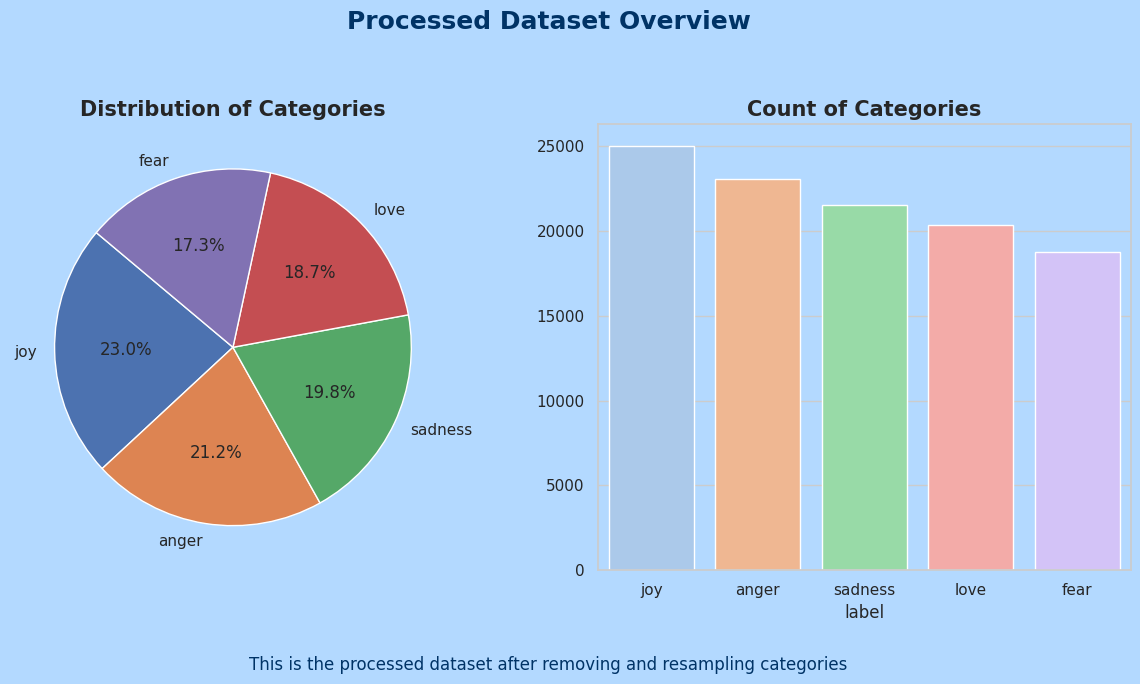

In [7]:
emotion_map = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',
    # Add more mappings as needed
}

ec_dataset['label'] = ec_dataset['label'].map(emotion_map)

# Count the values for each category
count = ec_dataset['label'].value_counts()

# Set a lighter blue background color and theme
background_color = '#b3d9ff'
sns.set_theme(style="whitegrid", rc={"axes.facecolor": background_color, 'figure.facecolor': background_color})

# Create a figure with two subplots and a title
fig, axs = plt.subplots(1, 2, figsize=(12, 6), facecolor=background_color)
fig.suptitle("Processed Dataset Overview", fontsize=18, fontweight='bold', color='#003366', y=1.05)

# Plot a pie chart on the first subplot
palette = sns.color_palette("pastel", len(count))
sns.set_palette(palette)
axs[0].pie(count, labels=count.index, autopct='%1.1f%%', startangle=140)
axs[0].set_title('Distribution of Categories', fontsize=15, fontweight='bold')

# Plot a bar chart on the second subplot
sns.barplot(x=count.index, y=count.values, ax=axs[1], palette=palette)
axs[1].set_title('Count of Categories', fontsize=15, fontweight='bold')

# Add subtitle
fig.text(0.5, -0.05, "This is the processed dataset after removing and resampling categories", ha='center', fontsize=12, color='#003366')

# Adjust layout for aesthetics
plt.tight_layout()

# Show the plot
plt.show()

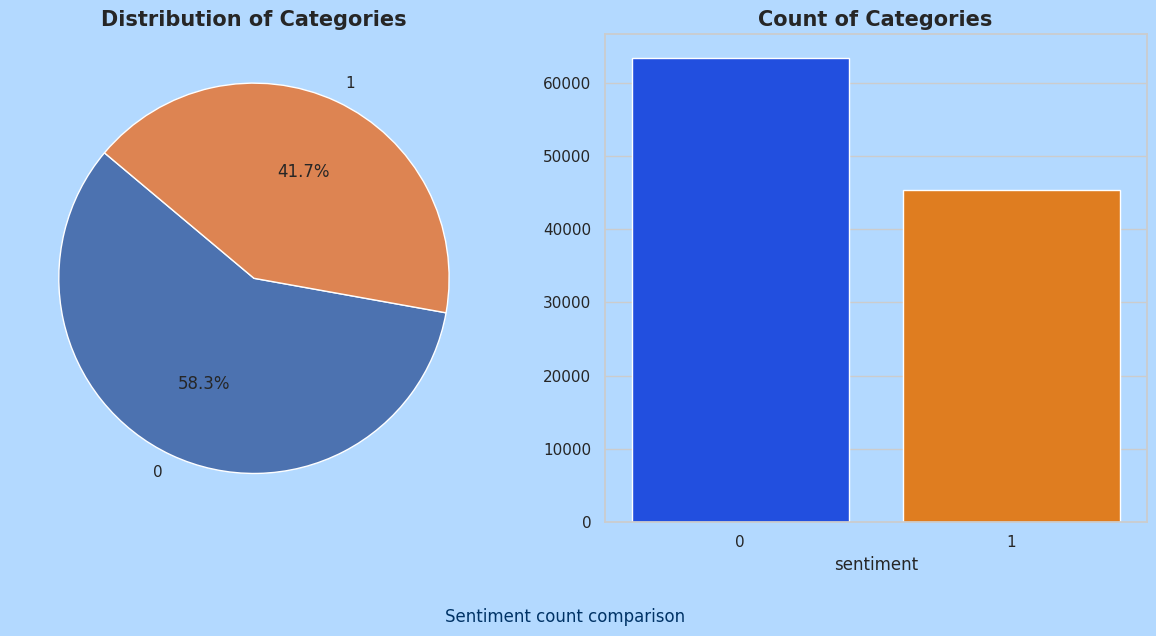

In [8]:
# Value count of 'sentiment'
count = ec_dataset['sentiment'].value_counts()

# Set the background color and theme
background_color = '#b3d9ff'
sns.set_theme(style="whitegrid", rc={"axes.facecolor": background_color, 'figure.facecolor': background_color})

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6), facecolor=background_color)

# Plot pie chart on the first subplot
palette = sns.color_palette("bright", len(count))
sns.set_palette(palette)
axs[0].pie(count, labels=count.index, autopct='%1.1f%%', startangle=140)
axs[0].set_title('Distribution of Categories', fontsize=15, fontweight='bold')

# Plot bar chart on the second subplot
sns.barplot(x=count.index, y=count.values, ax=axs[1], palette=palette)
axs[1].set_title('Count of Categories', fontsize=15, fontweight='bold')

# Add subtitle
fig.text(0.5, -0.05, "Sentiment count comparison", ha='center', fontsize=12, color='#003366')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [9]:
# Specify a different encoding to read the CSV file
neutral = pd.read_csv('/kaggle/input/twitter-sentiment-dataset/Twitter_Data.csv')

In [10]:
neutral.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [11]:
print(neutral['category'].value_counts())

category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64


In [12]:
# Filter the DataFrame to keep only rows where sentiment is 'neutral'
neutral_only = neutral[neutral['category'] == 0.0]

# Display the filtered DataFrame to confirm
print(neutral_only.head())
print("Number of neutral records:", neutral_only.shape[0])

                                           clean_text  category
1   talk all the nonsense and continue all the dra...       0.0
5            kiya tho refresh maarkefir comment karo        0.0
6   surat women perform yagna seeks divine grace f...       0.0
7   this comes from cabinet which has scholars lik...       0.0
13  one vote can make all the difference anil kapo...       0.0
Number of neutral records: 55213


In [13]:
neutral_only.head(20)

,clean_text,category
1,talk all the nonsense and continue all the dra...,0.0
5,kiya tho refresh maarkefir comment karo,0.0
6,surat women perform yagna seeks divine grace f...,0.0
7,this comes from cabinet which has scholars lik...,0.0
13,one vote can make all the difference anil kapo...,0.0
14,one vote can make all the difference anil kapo...,0.0
16,vote modi who has not created jobs,0.0
17,through our vote ensure govt need and deserve ...,0.0
22,crush jaws those who shoutmodimodi says jds ml...,0.0
26,has already taken notice and ordered probe now...,0.0


In [14]:
# Rename the third column to 'sentiment' and the last column to 'text'
neutral_only.columns = ['text', 'sentiment']

# Display the cleaned dataset to verify
print(neutral_only.head())

                                                 text  sentiment
1   talk all the nonsense and continue all the dra...        0.0
5            kiya tho refresh maarkefir comment karo         0.0
6   surat women perform yagna seeks divine grace f...        0.0
7   this comes from cabinet which has scholars lik...        0.0
13  one vote can make all the difference anil kapo...        0.0


In [15]:
neutral_only.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55213 entries, 1 to 162978
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   text       55211 non-null  object 
 1   sentiment  55213 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.3+ MB


In [16]:
# Drop rows where 'text' column is null
neutral_only = neutral_only.dropna(subset=['text'])

# Remove duplicate rows based on 'sentiment' and 'text' columns
neutral_only = neutral_only.drop_duplicates(subset=['sentiment', 'text'])

# Display the cleaned dataset to verify
print(neutral_only.head())
print(f"Number of rows after cleaning: {neutral_only.shape[0]}")

neutral_only.info()

                                                 text  sentiment
1   talk all the nonsense and continue all the dra...        0.0
5            kiya tho refresh maarkefir comment karo         0.0
6   surat women perform yagna seeks divine grace f...        0.0
7   this comes from cabinet which has scholars lik...        0.0
13  one vote can make all the difference anil kapo...        0.0
Number of rows after cleaning: 55211
<class 'pandas.core.frame.DataFrame'>
Index: 55211 entries, 1 to 162978
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   text       55211 non-null  object 
 1   sentiment  55211 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.3+ MB


In [17]:
# Display the first five complete sentences in the 'text' column
for i, sentence in enumerate(neutral_only['text'].head(50)):
    print(f"Sentence {i+1}: {sentence}")

Sentence 1: talk all the nonsense and continue all the drama will vote for modi 
Sentence 2: kiya tho refresh maarkefir comment karo 
Sentence 3: surat women perform yagna seeks divine grace for narendra modi become again

Sentence 4: this comes from cabinet which has scholars like modi smriti and hema time introspect
Sentence 5: one vote can make all the difference anil kapoor answers modis election 2019 clarion call extends support his vote kar campaign 
Sentence 6: one vote can make all the difference anil kapoor answers modis election 2019 clarion call extends support his campaign 
Sentence 7: vote modi who has not created jobs
Sentence 8: through our vote ensure govt need and deserve anupam kher responds modis appeal for the 2019 elections 
Sentence 9: crush jaws those who shoutmodimodi says jds mla this inciting murder
Sentence 10: has already taken notice and ordered probe now time for modi take notice muslim family being harassed beaten recently extremist hindus and was suggest

In [18]:
# Counting occurrences of the word "modi" in the 'text' column of neutral_only
modi_count = neutral_only['text'].str.contains('modi', case=False, na=False).sum()
print(modi_count)

49365


In [19]:
# Remove occurrences of the word "modi" (case-insensitive) in the 'text' column
neutral_only['text'] = neutral_only['text'].str.replace(r'\bmodi\b', '', case=False, regex=True)

# Display the first few rows to verify
print(neutral_only.head())

                                                 text  sentiment
1   talk all the nonsense and continue all the dra...        0.0
5            kiya tho refresh maarkefir comment karo         0.0
6   surat women perform yagna seeks divine grace f...        0.0
7   this comes from cabinet which has scholars lik...        0.0
13  one vote can make all the difference anil kapo...        0.0


In [20]:
keep_fraction = 0.4
rows_to_keep = int(len(neutral_only) * keep_fraction)

# Randomly sample 40% of the rows from `neutral_only`
neutral_only_reduced = neutral_only.sample(n=rows_to_keep, random_state=42)

# Reset the index of the reduced DataFrame (optional)
neutral_only_reduced.reset_index(drop=True, inplace=True)

# Display the first few rows to verify
print(neutral_only_reduced.head())
print(f"Original size: {len(neutral_only)}, Reduced size: {len(neutral_only_reduced)}")

                                                text  sentiment
0  hating  congress undermining matters national ...        0.0
1  besides attack was not planned  has just given...        0.0
2  only  can protect nations borders you all are ...        0.0
3  \nscience for soil health – farmers welfare th...        0.0
4     why what has happened now that  has announced         0.0
Original size: 55211, Reduced size: 22084


In [21]:
# Update the sentiment label to 2
neutral_only_reduced['sentiment'] = 2

# Insert a new column 'emotion' with a constant value of 5
neutral_only_reduced.insert(1, 'label', 5)

# Display the first few rows to verify
print(neutral_only_reduced.head())

                                                text  label  sentiment
0  hating  congress undermining matters national ...      5          2
1  besides attack was not planned  has just given...      5          2
2  only  can protect nations borders you all are ...      5          2
3  \nscience for soil health – farmers welfare th...      5          2
4     why what has happened now that  has announced       5          2


In [50]:
final = pd.read_csv('/kaggle/working/updated_ec_dataset.csv')
print(final.head())

                                                text  label  sentiment
0  i do feel that the parents should have been mo...      2          1
1  i learned to ignore the feeling of exhaustion ...      2          1
2  i could really embarrass him but i m feeling g...      2          1
3                        ive been feeling hot lately      2          1
4  iodine even made Associate_in_Nursing acceptab...      2          1


In [51]:
final.head()

,text,label,sentiment
0,i do feel that the parents should have been mo...,2,1
1,i learned to ignore the feeling of exhaustion ...,2,1
2,i could really embarrass him but i m feeling g...,2,1
3,ive been feeling hot lately,2,1
4,iodine even made Associate_in_Nursing acceptab...,2,1


In [52]:
final.head()
print(final['label'].value_counts())

label
1    25040
3    23087
0    21539
2    20354
4    18791
Name: count, dtype: int64


In [55]:
combined_dataset = pd.concat([final, neutral_only_reduced], ignore_index=True)

# Shuffle the combined dataset
combined_dataset = combined_dataset.sample(frac=1, random_state=42).reset_index(drop=True)

# Display the first few rows to verify
print(combined_dataset.head())

                                                text  label  sentiment
0  i do think feel is on this web_log basically m...      2          1
1  i know information_technology s not funny but ...      3          0
2  i didnt feel like this and longing for my very...      2          1
3  i dont take my medicine i feel horrible and pa...      0          0
4  i ended up feeling terrible about everything i...      0          0


In [56]:
print(combined_dataset['label'].value_counts())

label
1    25040
3    23087
5    22084
0    21539
2    20354
4    18791
Name: count, dtype: int64


In [62]:
combined_dataset.to_csv('final_ec_dataset.csv', index=False)

print("The updated dataset has been saved as 'final_ec_dataset.csv'.")

The updated dataset has been saved as 'final_ec_dataset.csv'.


In [63]:
# Load the dataset
final_ec_dataset = pd.read_csv('final_ec_dataset.csv')

# Split the dataset into training and testing sets (80% training, 20% testing)
train_data, test_data = train_test_split(final_ec_dataset, test_size=0.2, random_state=42)

# Save the training and testing sets to separate CSV files
train_data.to_csv('final_ec_dataset_train.csv', index=False)
test_data.to_csv('final_ec_dataset_test.csv', index=False)

print("Training and testing datasets have been saved as 'final_ec_dataset_train.csv' and 'final_ec_dataset_test.csv'.")

Training and testing datasets have been saved as 'final_ec_dataset_train.csv' and 'final_ec_dataset_test.csv'.


In [64]:
final_ec_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130895 entries, 0 to 130894
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   text       130895 non-null  object
 1   label      130895 non-null  int64 
 2   sentiment  130895 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.0+ MB


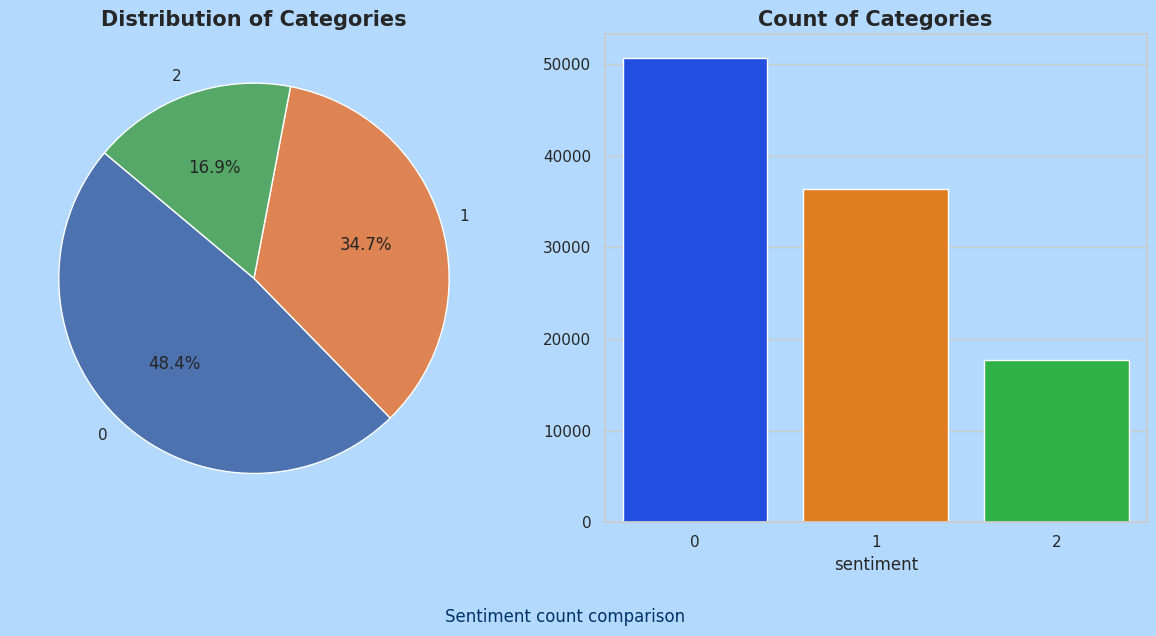

In [65]:
final_ec_dataset = pd.read_csv("/kaggle/working/final_ec_dataset_train.csv")

# Value count of 'sentiment'
count = final_ec_dataset['sentiment'].value_counts()

# Set the background color and theme
background_color = '#b3d9ff'
sns.set_theme(style="whitegrid", rc={"axes.facecolor": background_color, 'figure.facecolor': background_color})

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6), facecolor=background_color)

# Plot pie chart on the first subplot
palette = sns.color_palette("bright", len(count))
sns.set_palette(palette)
axs[0].pie(count, labels=count.index, autopct='%1.1f%%', startangle=140)
axs[0].set_title('Distribution of Categories', fontsize=15, fontweight='bold')

# Plot bar chart on the second subplot
sns.barplot(x=count.index, y=count.values, ax=axs[1], palette=palette)
axs[1].set_title('Count of Categories', fontsize=15, fontweight='bold')

# Add subtitle
fig.text(0.5, -0.05, "Sentiment count comparison", ha='center', fontsize=12, color='#003366')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

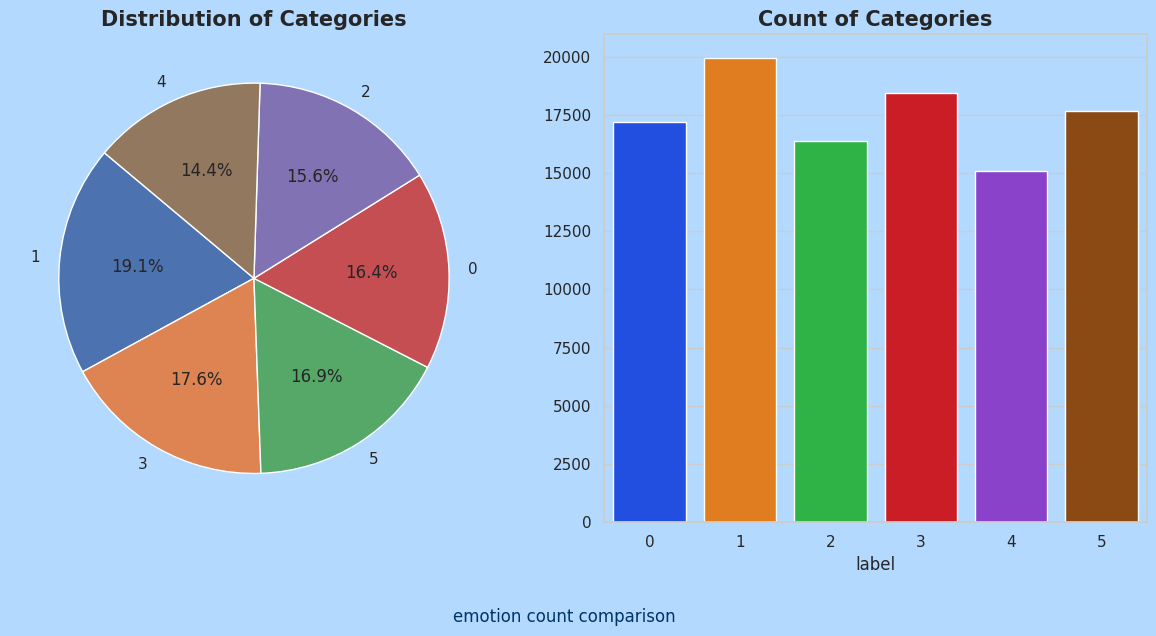

In [66]:
final_ec_dataset = pd.read_csv("/kaggle/working/final_ec_dataset_train.csv")

# Value count of 'sentiment'
count = final_ec_dataset['label'].value_counts()

# Set the background color and theme
background_color = '#b3d9ff'
sns.set_theme(style="whitegrid", rc={"axes.facecolor": background_color, 'figure.facecolor': background_color})

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6), facecolor=background_color)

# Plot pie chart on the first subplot
palette = sns.color_palette("bright", len(count))
sns.set_palette(palette)
axs[0].pie(count, labels=count.index, autopct='%1.1f%%', startangle=140)
axs[0].set_title('Distribution of Categories', fontsize=15, fontweight='bold')

# Plot bar chart on the second subplot
sns.barplot(x=count.index, y=count.values, ax=axs[1], palette=palette)
axs[1].set_title('Count of Categories', fontsize=15, fontweight='bold')

# Add subtitle
fig.text(0.5, -0.05, "emotion count comparison", ha='center', fontsize=12, color='#003366')

# Adjust layout
plt.tight_layout()

# Show the plot

# 5. Coclusion
Eventually, the dataset is quite balanced in the aspect of the emotion class, with 104,716 training data, and 26,179 testing data

<bound method NDFrame.head of        Unnamed: 0  is_sarcastic  \
0               0             1   
1               1             0   
2               2             0   
3               3             1   
4               4             1   
...           ...           ...   
28614       28614             1   
28615       28615             1   
28616       28616             0   
28617       28617             1   
28618       28618             1   

                                                headline  
0      thirtysomething scientists unveil doomsday clo...  
1      dem rep. totally nails why congress is falling...  
2      eat your veggies: 9 deliciously different recipes  
3      inclement weather prevents liar from getting t...  
4      mother comes pretty close to using word 'strea...  
...                                                  ...  
28614       jews to celebrate rosh hashasha or something  
28615  internal affairs investigator disappointed con...  
28616  the most be

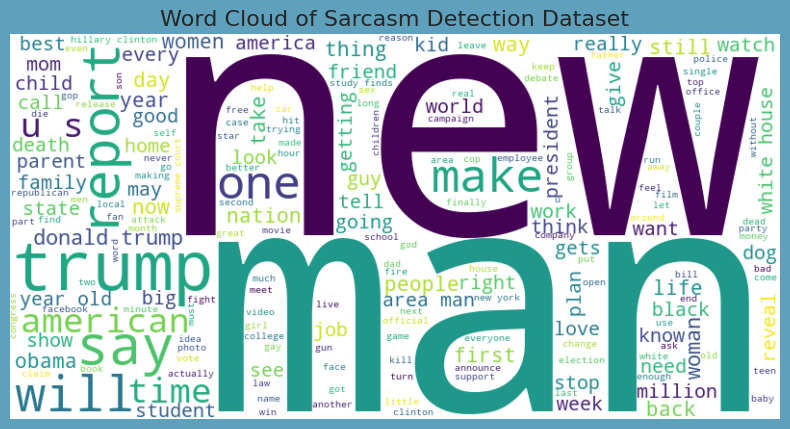

In [11]:
SD_dataset = pd.read_csv(r"/kaggle/input/thesis2-dataset/sarcasm_dataset.csv")
print(SD_dataset.head)

# Combine all text data into a single string
text_data = " ".join(SD_dataset["headline"].astype(str))

# Create a word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text_data)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Sarcasm Detection Dataset", fontsize=16)
plt.show()

In [12]:
print(SD_dataset['is_sarcastic'].value_counts())

is_sarcastic
0    14985
1    13634
Name: count, dtype: int64
